<a href="https://colab.research.google.com/github/morphineo/GEE-LULC-2015-2025/blob/main/2020_Sample_LULC_Code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap
ee.Authenticate()
ee.Initialize(project='ndvi-projects')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


#load the data:

In [2]:
from pprint import pprint

In [3]:
# Load the geometry:
aoi = ee.FeatureCollection('projects/ndvi-projects/assets/maucomplex')

In [4]:
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = (qa.bitwiseAnd(cloud_bit_mask).eq(0)
              .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0)))
    return image.updateMask(mask).divide(10000)

def select_bands(image):
    # 1. Spectral indices
    ndvi   = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi   = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    mndwi  = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    ndsli  = image.normalizedDifference(['B4', 'B11']).rename('NDSLI')
    rendvi = image.normalizedDifference(['B8', 'B5']).rename('reNDVI')
    gndvi  = image.normalizedDifference(['B8', 'B3']).rename('GNDVI')
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * (1.5)',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('SAVI')

    # 2. Topography (helps separate tea from transitional vegetation)
    terrain = ee.Algorithms.Terrain(ee.Image('USGS/SRTMGL1_003'))
    elevation = terrain.select('elevation')
    slope = terrain.select('slope')

    # 3. Bands to keep (B5 is needed for the red-edge index)
    bands = ['B4', 'B3', 'B2', 'B5', 'B8', 'B11', 'B12']

    # 4. Return bands + indices + topography to the classifier
    return (image.select(bands)
                 .addBands([ndvi, mndwi, ndbi, ndsli, rendvi, gndvi, savi, elevation, slope]))

#Load training and Validation data

In [5]:
train = ee.FeatureCollection('projects/ndvi-projects/assets/Training_Points_2020')
validation = ee.FeatureCollection('projects/ndvi-projects/assets/Validation_Points_2020')

# In Python, .getInfo() brings server-side results down so they can be printed
print('Total training polygons:', train.size().getInfo())
print('Training class distribution:', train.aggregate_histogram('LULC').getInfo())
print('Total validation polygons:', validation.size().getInfo())
print('Validation class distribution:', validation.aggregate_histogram('LULC').getInfo())

Total training polygons: 200
Training class distribution: {'1': 30, '2': 30, '3': 30, '4': 30, '5': 30, '6': 20, '7': 30}
Total validation polygons: 200
Validation class distribution: {'1': 30, '2': 30, '3': 30, '4': 30, '5': 30, '6': 20, '7': 30}


#Sample the imagery at the training and validation locations

In [6]:
imagery = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterDate('2020-12-20', '2020-12-24')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
           .filterBounds(aoi)
           .map(mask_s2_clouds)
           .map(lambda img: img.clip(aoi))
           .median())

imagery = select_bands(imagery)
print('Bands used by the classifier:', imagery.bandNames().getInfo())

Bands used by the classifier: ['B4', 'B3', 'B2', 'B5', 'B8', 'B11', 'B12', 'NDVI', 'MNDWI', 'NDBI', 'NDSLI', 'reNDVI', 'GNDVI', 'SAVI', 'elevation', 'slope']


In [7]:
train_sample = imagery.sampleRegions(
    collection=train,
    properties=['LULC'],
    scale=10,
    tileScale=16
)

test_sample = imagery.sampleRegions(
    collection=validation,
    properties=['LULC'],
    scale=10,
    tileScale=16
)

#Random Forest classifier:

In [8]:
rf_model = ee.Classifier.smileRandomForest(
    numberOfTrees=150,
    minLeafPopulation=5,
    bagFraction=0.5,
    seed=0
).train(
    features=train_sample,
    classProperty='LULC',
    inputProperties=imagery.bandNames()
)

<BarContainer object of 16 artists>

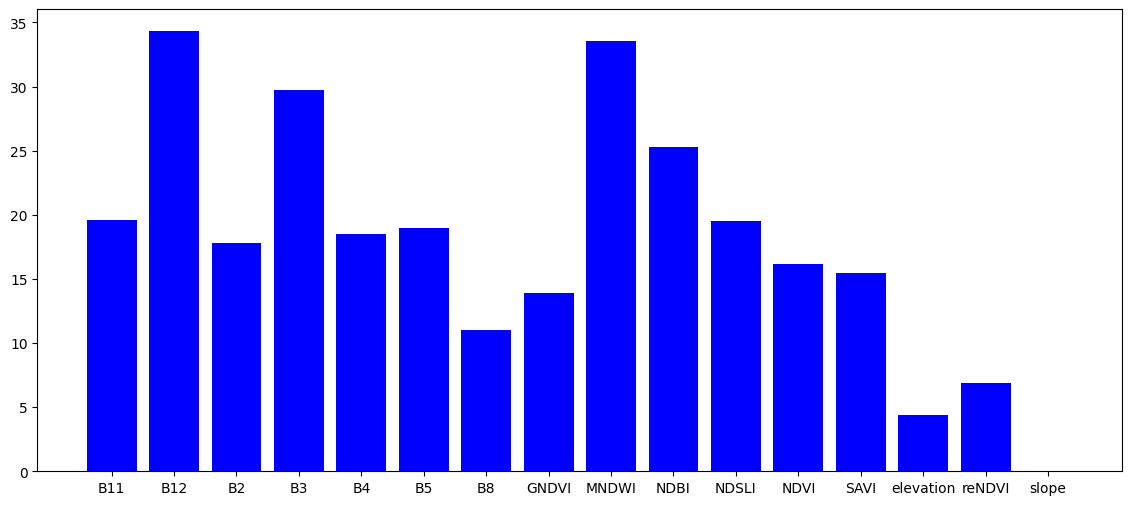

In [9]:
variable_importance = ee.Feature(None, ee.Dictionary(rf_model.explain()).get('importance')).getInfo()
import matplotlib.pyplot as plt
import numpy as np
fi = np.array(list(variable_importance.get('properties').values()))
name_bands = np.array(list(variable_importance.get('properties').keys()))
plt.figure(figsize=(14,6))
plt.bar(name_bands, fi, color="b",
        align="center")

<BarContainer object of 16 artists>

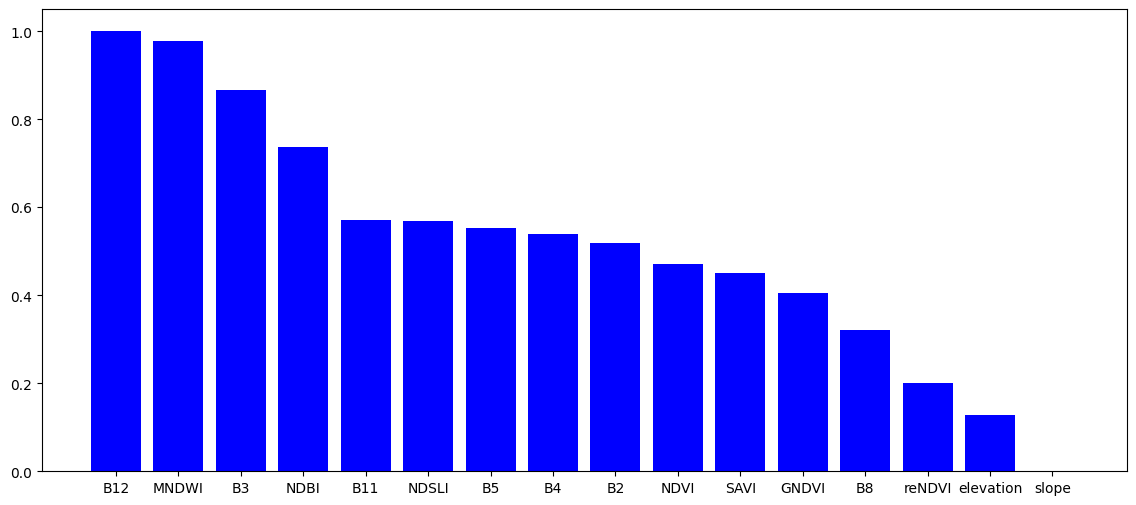

In [10]:
fi_or = fi[np.argsort(fi, axis=None)[::-1]]
fi_or = fi_or/np.max(fi_or)
name_bands_or = name_bands[np.argsort(fi, axis=None)[::-1]]
plt.figure(figsize=(14,6))
plt.bar(name_bands_or, fi_or, color="b", align="center")

In [11]:
import itertools

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right', fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    thresh = cm.max() / 2.
    fmt = '.2f' if normalize else 'd'
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), ha='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.ylabel('True label', fontsize=13)
    plt.xlabel('Predicted label', fontsize=13)
    plt.tight_layout()

Training overall accuracy (%): 99.0
Training Kappa: 0.9883040935672515


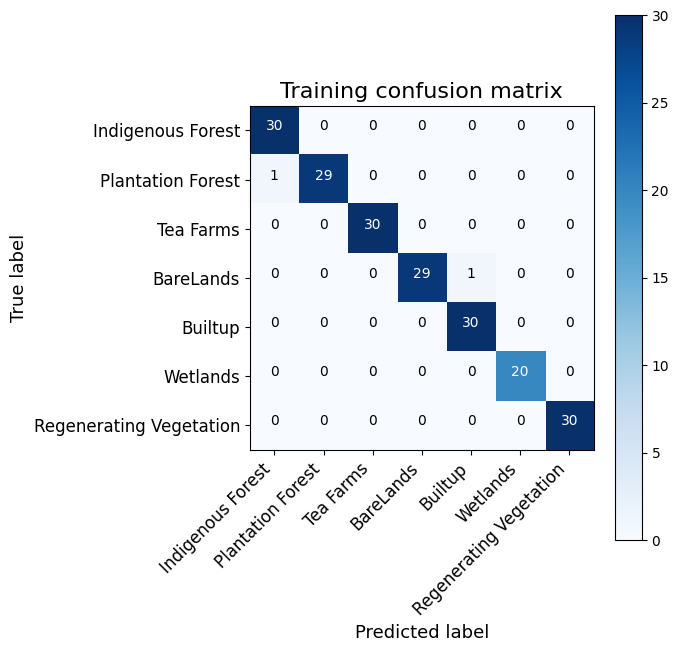

In [12]:
classes_names = ['Indigenous Forest', 'Plantation Forest', 'Tea Farms', 'BareLands',
                 'Builtup', 'Wetlands', 'Regenerating Vegetation']

train_cm = rf_model.confusionMatrix()
print('Training overall accuracy (%):', train_cm.accuracy().getInfo() * 100)
print('Training Kappa:', train_cm.kappa().getInfo())

CM = np.array(train_cm.getInfo())
if CM.shape[0] == len(classes_names) + 1:   # drop the empty class-0 row/column
    CM = CM[1:, 1:]
CM = CM.astype(int)

plt.figure(figsize=(7, 7))
plot_confusion_matrix(CM, classes_names, title='Training confusion matrix')
plt.show()

Test overall accuracy (%):  91.5
Test kappa:  0.9005266237565829


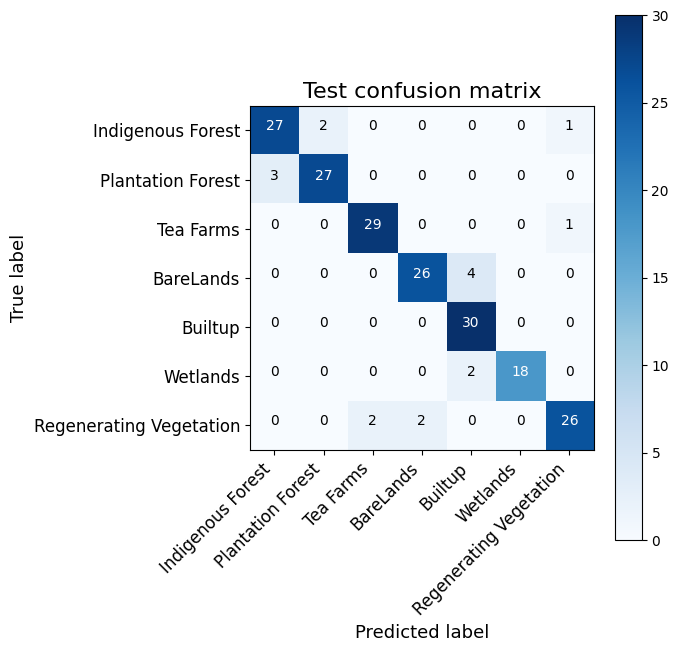

In [13]:
# Calculate the statistics of the classifier in the test set:
classifiedTest = test_sample.classify(rf_model)
# print('Test prediction', classifiedTest)

class_order = [1, 2, 3, 4, 5, 6, 7]
testAccuracy = classifiedTest.errorMatrix('LULC', 'classification', class_order)

print('Test overall accuracy (%): ', testAccuracy.accuracy().getInfo() * 100)
print('Test kappa: ', testAccuracy.kappa().getInfo())

CM = np.array(testAccuracy.getInfo()).astype(int)
f = plt.figure(figsize=(7, 7))
plot_confusion_matrix(CM, classes_names, normalize=False,
                      title='Test confusion matrix', cmap=plt.cm.Blues)
plt.show()

#Classify the image and show it on a map

In [14]:
!pip install -q geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.9 MB/s eta 0:00:00


In [15]:
# Classify the whole image using our processed imagery and trained RF model
classified = imagery.classify(rf_model)

# Create the map with a satellite basemap (avoids the blocked OpenStreetMap tiles)
Map = geemap.Map()
Map.add_basemap('HYBRID')
Map.centerObject(aoi, 11)

# Display the true-color S2 image
rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 0.3,
    'gamma': 1.4
}
Map.addLayer(imagery, rgb_vis, 'Sentinel-2 Image')

# Display the classification map
class_vis = {
    'min': 1,
    'max': 7,
    'palette': ['00441b', '7fbc41', 'FFFF00', '8c510a', '000000', '4575b4', 'ff00ff'],
    'opacity': 0.85
}
Map.addLayer(classified, class_vis, 'LULC Classification')

# Add legend
legend_keys = ['Indigenous Forest', 'Plantation Forest', 'Tea Farms', 'Bare Lands',
               'Built-up', 'Wetlands', 'Regenerating Vegetation']
legend_colors = ['#00441b', '#7fbc41', '#FFFF00', '#8c510a', '#000000', '#4575b4', '#ff00ff']
Map.add_legend(keys=legend_keys, colors=legend_colors, position='bottomright')

Map

Map(center=[-0.36757951972616226, 35.358783682870836], controls=(WidgetControl(options=['position', 'transpare…